In [75]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

In [76]:
ekf_ed_low = 0.325
ekf_md_low = 3.569
ekf_det_low = 3.023e-8

ekf_ed_mid = 5.493
ekf_md_mid = 9.959
ekf_det_mid = 0.0136

ekf_ed_high = 35.163
ekf_md_high = 9.345
ekf_det_high = 15740

In [77]:
ukf_ed_low = 0.325
ukf_md_low = 3.4501
ukf_det_low = 2.688e-8

ukf_ed_mid = 5.80
ukf_md_mid = 12.10
ukf_det_mid = 4.03

ukf_ed_high = 66.78
ukf_md_high = 25.17
ukf_det_high = 7262.42

In [78]:
bnkf_ed_low = 1.048
bnkf_md_low = 1.7198
bnkf_det_low = 0.0998 

bnkf_ed_mid = 4.92
bnkf_md_mid = 5.43
bnkf_det_mid = 1.695

bnkf_ed_high = 8.627
bnkf_md_high = 5.675 
bnkf_det_high = 13.656

In [79]:
bnkfe_ed_low = 0.91
bnkfe_md_low = 2.03
bnkfe_det_low = 0.02

bnkfe_ed_mid = 4.81
bnkfe_md_mid = 7.61
bnkfe_det_mid = 0.02

bnkfe_ed_high = 9.24
bnkfe_md_high = 7.11 
bnkfe_det_high = 8.11

In [80]:
bnn_ed_low = 5.83
bnn_md_low = 6.20
bnn_det_low = 7.31

bnn_ed_mid = 7.31
bnn_md_mid = 6.23
bnn_det_mid = 49.22

bnn_ed_high = 13.13
bnn_md_high = 8.94
bnn_det_high = 102.26

In [81]:
labels = ['Low', 'Mid', 'High']
ed_ekf_mean = [ekf_ed_low, ekf_ed_mid, ekf_ed_high]
ed_bnkf_mean = [bnkf_ed_low, bnkf_ed_mid, bnkf_ed_high]
ed_bnkfe_mean = [bnkfe_ed_low, bnkfe_ed_mid, bnkfe_ed_high]
ed_ukf_mean = [ukf_ed_low, ukf_ed_mid, ukf_ed_high]
ed_bnn_mean = [bnn_ed_low, bnn_ed_mid, bnn_ed_high]

md_ekf_mean = [ekf_md_low, ekf_md_mid, ekf_md_high]
md_bnkf_mean = [bnkf_md_low, bnkf_md_mid, bnkf_md_high]
md_bnkfe_mean = [bnkfe_md_low, bnkfe_md_mid, bnkfe_md_high]
md_ukf_mean = [ukf_md_low, ukf_md_mid, ukf_md_high]
md_bnn_mean = [bnn_md_low, bnn_md_mid, bnn_md_high]

det_ekf_mean = [ekf_det_low, ekf_det_mid, ekf_det_high]
det_bnkf_mean = [bnkf_det_low, bnkf_det_mid, bnkf_det_high]
det_bnkfe_mean = [bnkfe_det_low, bnkfe_det_mid, bnkfe_det_high]
det_ukf_mean = [ukf_det_low, ukf_det_mid, ukf_det_high]
det_bnn_mean = [bnn_det_low, bnn_det_mid, bnn_det_high]

x = np.arange(len(labels))
width = 0.2

In [82]:
ed_ekf_std = [0, 0 , 0]
ed_ukf_std = [0, 0, 0]
ed_bnkf_std = [0.52, 0.03, 0.18]
ed_bnkfe_std = [0.05, 0.08, 0.13]
ed_bnn_std = [0.32, 0.41, 0.33]

md_ekf_std = [0, 0 , 0]
md_ukf_std = [0, 0, 0]
md_bnkf_std = [0.52, 0.09, 0.15]
md_bnkfe_std = [0.07, 0.42, 0.36]
md_bnn_std = [0.52, 0.32, 0.19]

# det_ekf_std = [0, 0 , 0]
# det_ukf_std = [0, 0, 0]
# det_bnkf_std = [0.08, 29.79, 59.22]
# det_bnkfe_std = [0.08, 29.79, 59.22]
# det_bnn_std = [7.31, 12.18, 24.82]

det_ekf_std = [0, 0 , 0]
det_ukf_std = [0, 0, 0]
det_bnkf_std = [0, 0 , 0]
det_bnkfe_std = [0, 0 , 0]
det_bnn_std = [0, 0 , 0]

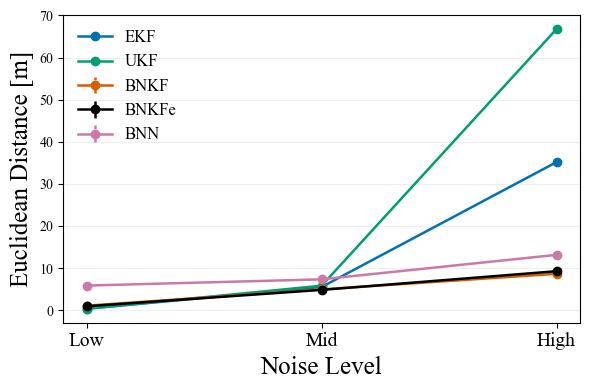

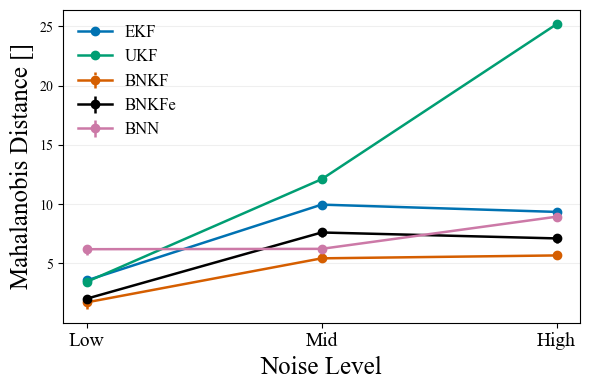

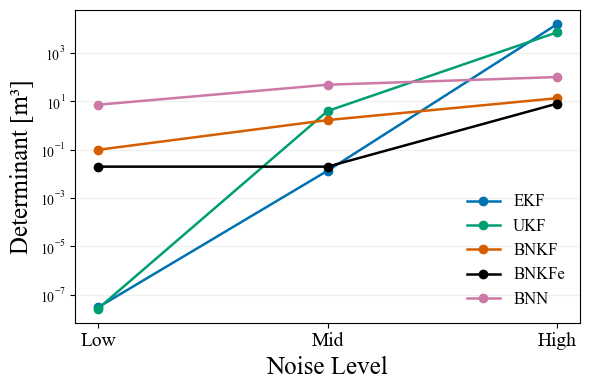

In [83]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Low', 'Mid', 'High']
x = np.arange(len(labels))

# colorblind-safe palette (Okabe–Ito + black + purple for BNN)
colors = {
    "EKF":   "#0072B2",   # blue
    "UKF":   "#009E73",   # green
    "BNKF":  "#D55E00",   # orange
    "BNKFe": "#000000",   # black
    "BNN":   "#CC79A7",   # purple (Okabe–Ito)
}

def plot_metric_with_sigma(
    ax, x, labels,
    means_dict, stds_dict,
    ylabel,
    logy=False,
    outfile=None
):
    for name, y in means_dict.items():
        yerr = stds_dict.get(name, None)

        # If no std provided, or it's all zeros, just plot the mean line
        if yerr is None or np.all(np.asarray(yerr) == 0):
            ax.plot(
                x, y,
                marker='o',
                linestyle='-',
                linewidth=1.8,
                label=name,
                color=colors[name]
            )
            continue

        # errorbar version (solid mean line + dashed error bars)
        line = ax.errorbar(
            x, y, yerr=yerr,
            marker='o',
            linestyle='-',
            linewidth=1.8,
            elinewidth=1.8,
            label=name,
            color=colors[name],
            capsize=0
        )
        for bar in line[2]:
            bar.set_linestyle('--')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_xlabel('Noise Level', fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)

    if logy:
        ax.set_yscale('log')

    ax.margins(x=0.05)
    ax.grid(axis='y', alpha=0.2)
    ax.legend(fontsize=12, frameon=False, loc='best')

    plt.tight_layout()
    if outfile is not None:
        plt.savefig(outfile, dpi=300)


# ---------- ED plot ----------
fig, ax = plt.subplots(figsize=(6,4))
plot_metric_with_sigma(
    ax, x, labels,
    means_dict={
        "EKF": ed_ekf_mean,
        "UKF": ed_ukf_mean,
        "BNKF": ed_bnkf_mean,
        "BNKFe": ed_bnkfe_mean,
        "BNN": ed_bnn_mean,
    },
    stds_dict={
        "EKF": ed_ekf_std,
        "UKF": ed_ukf_std,
        "BNKF": ed_bnkf_std,
        "BNKFe": ed_bnkfe_std,
        "BNN": ed_bnn_std,
    },
    ylabel='Euclidean Distance [m]',
    logy=False,
    outfile='../../report/results_revamp_img/ed_trend_lines.png'
)
plt.show()


# ---------- MD plot ----------
fig, ax = plt.subplots(figsize=(6,4))
plot_metric_with_sigma(
    ax, x, labels,
    means_dict={
        "EKF": md_ekf_mean,
        "UKF": md_ukf_mean,
        "BNKF": md_bnkf_mean,
        "BNKFe": md_bnkfe_mean,
        "BNN": md_bnn_mean,
    },
    stds_dict={
        "EKF": md_ekf_std,
        "UKF": md_ukf_std,
        "BNKF": md_bnkf_std,
        "BNKFe": md_bnkfe_std,
        "BNN": md_bnn_std,
    },
    ylabel='Mahalanobis Distance []',
    logy=False,
    outfile='../../report/results_revamp_img/md_trend_lines.png'
)
plt.show()


# ---------- DET plot (log scale) ----------
fig, ax = plt.subplots(figsize=(6,4))
plot_metric_with_sigma(
    ax, x, labels,
    means_dict={
        "EKF": det_ekf_mean,
        "UKF": det_ukf_mean,
        "BNKF": det_bnkf_mean,
        "BNKFe": det_bnkfe_mean,
        "BNN": det_bnn_mean,
    },
    stds_dict={
        "EKF": det_ekf_std,
        "UKF": det_ukf_std,
        "BNKF": det_bnkf_std,
        "BNKFe": det_bnkfe_std,
        "BNN": det_bnn_std,
    },
    ylabel='Determinant [m³]',
    logy=True,
    outfile='../../report/results_revamp_img/det_trend_lines.png'
)
plt.show()

### Averaged Plot

In [84]:
ekf_avg_md = np.mean(md_ekf_mean)
bnkf_avg_md = np.mean(md_bnkf_mean)
bnkfe_avg_md = np.mean(md_bnkfe_mean)
ukf_avg_md = np.mean(md_ukf_mean)
bnn_avg_md = np.mean(md_bnn_mean)

ekf_avg_det = np.mean(det_ekf_mean)
bnkf_avg_det = np.mean(det_bnkf_mean)
bnkfe_avg_det = np.mean(det_bnkfe_mean)
ukf_avg_det = np.mean(det_ukf_mean)
bnn_avg_det= np.mean(det_bnn_mean)

ekf_avg_ed = np.mean(ed_ekf_mean)
bnkf_avg_ed = np.mean(ed_bnkf_mean)
bnkfe_avg_ed = np.mean(ed_bnkfe_mean)
ukf_avg_ed = np.mean(ed_ukf_mean)
bnn_avg_ed = np.mean(ed_bnn_mean)

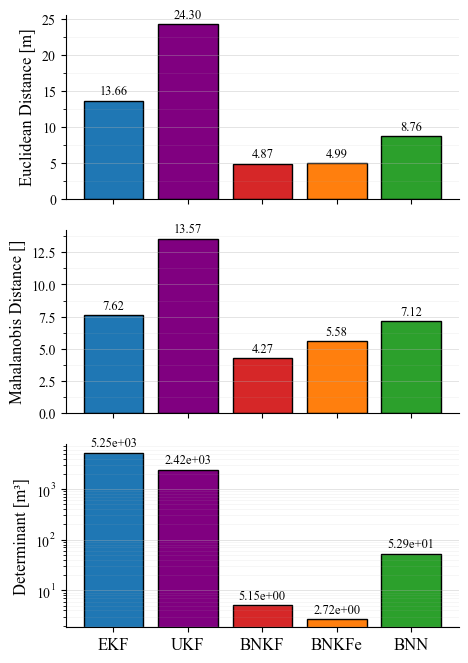

In [85]:
# Colors
colors = {
    "EKF":   "#1f77b4",  # blue
    "UKF":   "#800080",  # purple
    "BNKF":  "#d62728",  # red
    "BNKFe": "#ff7f0e",  # orange
    "BNN":   "#2ca02c",  # green (add BNN)
}

methods = ["EKF", "UKF", "BNKF", "BNKFe", "BNN"]
ed_avgs  = [ekf_avg_ed,  ukf_avg_ed,  bnkf_avg_ed,  bnkfe_avg_ed,  bnn_avg_ed]
md_avgs  = [ekf_avg_md,  ukf_avg_md,  bnkf_avg_md,  bnkfe_avg_md,  bnn_avg_md]
det_avgs = [ekf_avg_det, ukf_avg_det, bnkf_avg_det, bnkfe_avg_det, bnn_avg_det]

fig, axes = plt.subplots(3, 1, figsize=(4.75,6.75), sharex=True)

# Euclidean Distance
bars0 = axes[0].bar(methods, ed_avgs, color=[colors[m] for m in methods], edgecolor="black")
axes[0].set_ylabel("Euclidean Distance [m]", fontsize=12)
axes[0].bar_label(bars0, fmt="%.2f", fontsize=9, padding=2)

# Mahalanobis Distance
bars1 = axes[1].bar(methods, md_avgs, color=[colors[m] for m in methods], edgecolor="black")
axes[1].set_ylabel("Mahalanobis Distance []", fontsize=12)
axes[1].bar_label(bars1, fmt="%.2f", fontsize=9, padding=2)

# Determinant (log scale)
bars2 = axes[2].bar(methods, det_avgs, color=[colors[m] for m in methods], edgecolor="black")
axes[2].set_ylabel("Determinant [m³]", fontsize=12)
axes[2].set_yscale("log")
axes[2].bar_label(bars2, fmt="%.2e", fontsize=9, padding=2)  # scientific notation for clarity

# Cosmetics
for ax in axes:
    ax.tick_params(axis='x', labelrotation=0, labelsize=12)
    ax.grid(axis='y', alpha=0.3)

from matplotlib.ticker import AutoMinorLocator, LogLocator

# Linear panels: subtle minor grid on y
for ax in axes[:2]:
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(axis='y', which='major', linewidth=0.6, alpha=0.4)
    ax.grid(axis='y', which='minor', linewidth=0.4, alpha=0.2)

# Log panel: minor ticks at 2–9 within each decade
axes[2].yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)*0.1))
axes[2].grid(axis='y', which='major', linewidth=0.6, alpha=0.4)
axes[2].grid(axis='y', which='minor', linewidth=0.4, alpha=0.18)

# Clean spines for IEEE look
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../report/results_revamp_img/summary_barplots.png", dpi=300)
plt.show()

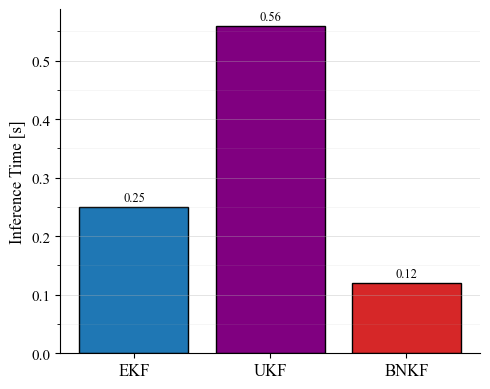

In [86]:
import os
from matplotlib.ticker import AutoMinorLocator

# Colors dictionary (same as bottom plots)
colors = {
    "EKF":   "#1f77b4",  # blue
    "UKF":   "#800080",  # purple
    "BNKF":  "#d62728",  # red
    "BNKFe": "#ff7f0e",  # orange
}

# Data (runtime averages)
methods  = ["EKF", "UKF", "BNKF"]
runtimes = [0.25, 0.56, 0.12]

# IEEE double-column width, compact height
fig, ax = plt.subplots(figsize=(5.0, 4.0))

# Bars with same colors & black edges
bars = ax.bar(methods, runtimes,
              color=[colors[m] for m in methods],
              edgecolor="black")

# Axis label
ax.set_ylabel("Inference Time [s]", fontsize=12)

# Add bar labels
ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)

# Gridlines like your bottom plots
ax.grid(axis='y', which='major', linewidth=0.6, alpha=0.4)
ax.grid(axis='y', which='minor', linewidth=0.4, alpha=0.2)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Cosmetics: ticks, spines
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("../../report/results_revamp_img/runtime_barplot.png", dpi=300)

plt.show()